#Práctica de Aprendizaje No Supervisado
##Estudiantes:
- Luis Ernesto Jaldin Merida
- Jhaddyn Brian Ortiz Alanoca

Dataset elegido: https://archive.ics.uci.edu/dataset/292/wholesale+customers

##Descripcion
* The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories

##Justificacion
###¿Por que se usara este dataset?
-> Se hara uso del dataset de Wholsesale customers por que cumple con los parametros que se piden en el trabajo:
* Almenos 100 Filas, en este caso 440 ✅
* 3 Columnas numericas, en este caso 8 ✅
* Tema donde tiene sentido buscar patrones, en este caso Clientes ✅
* Fuente recomendada -> UCI Machine Learning Repository ✅

###¿Que tipo de grupos esperas encontrar antes de analizarlo?
* Espero encontrar datos de que grupo sea el que tenga el mayor gasto anaul de entre todos (talvez sea "Fresh" productos o alimentos frescos) y tambien que grupo tiene el mayor gasto en por ejemplo Fresh y Frozen (talvez sea "Horeca" osea los hoteles, restaurantes, etc)

#Paso 2 - Exploracion de datos
##2.1 Cargar el dataset y mostrar las primeras filas


In [ ]:
# Paso 2 - Cargar dataset - Mostrar primeras filas
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('/Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


##2.2 Ejecuta .info() y .describe()

In [ ]:
# Ejecutar .info() .describe()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


##2.3 Identifica:
###¿cuántas filas y columnas tiene?
* -> Hay 440 filas y 8 columnas.
###¿hay valores nulos?
* -> No hay valores nulos.
###¿qué rango tiene cada variable numérica?
* -> fresh: entre 3 a 112151 unidad monetaria/año
* -> milk: entre 55 a 73498 unidad monetaria/año
* -> grocery: entre 3 a 92780 unidad monetaria/año
* -> frozen: entre 25 a 60869 unidad monetaria/año
* -> detergent_paper: entre 3 a 40827 unidad monetaria/año
* -> delicassen: entre 3 a 47943 unidad monetaria/año

##Haz al menos 2 gráficos exploratorios (histogramas o scatter plots) de las variables que planeas usar para clusterizar

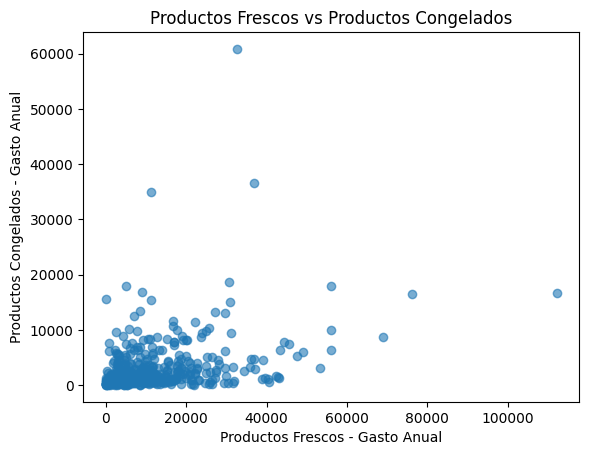

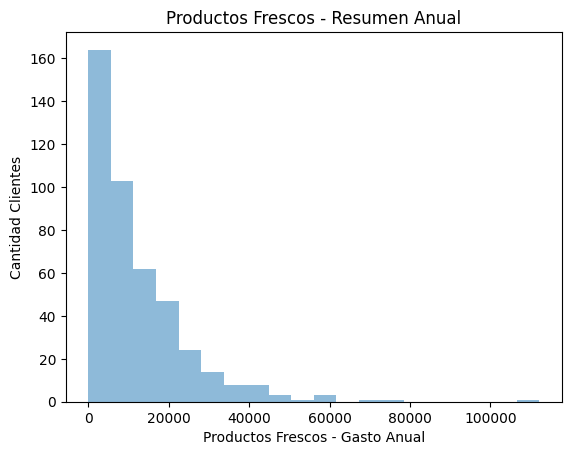

In [ ]:
#Scatter
plt.scatter(df['Fresh'], df['Frozen'], alpha=0.6)
plt.xlabel('Productos Frescos - Gasto Anual')
plt.ylabel('Productos Congelados - Gasto Anual')
plt.title('Productos Frescos vs Productos Congelados')
plt.show()

#Histograma
plt.hist(df['Fresh'], bins=20, alpha=0.5)
plt.ylabel('Cantidad Clientes')
plt.xlabel('Productos Frescos - Gasto Anual')
plt.title('Productos Frescos - Resumen Anual')
plt.show()

Justificación escrita: describe con tus propias palabras qué observas en tus gráficos. ¿Ya se nota a simple vista alguna agrupación o los datos parecen "una sola nube"? No copies una descripción genérica — decime específicamente qué ves en TUS datos.

* En cuanto al grafico de Scatter, en la comparativa de Productos frescos vs Productos congelados se puede ver que hay una gran mayoria de clientes que tanto en ambos casos se concentran por la primera parte: entre 0 a 10000 unidades monetarias / año en productos congelados Y entre 0 y 30000, 40000 unidades monetarias en productos frescos.

* En cuanto al grafico de Histograma, al usar el parametro de bins=20 es decir dividir el grafico en 20 barras se puede observar que la gran mayoria de clientes entre aprox 50 a 160 gastan entre 0 y 20000 unidades monetarias y estan agrupados aca.

###¿Ya se nota a simple vista alguna agrupación o los datos parecen "una sola nube"?
* Si, se nota una agrupacion de datos densa en valores bajos.

#Paso 3 — Selección de variables y escalado

##3.1 Elige al menos 3 variables numéricas para clusterizar

In [ ]:
# Variables para clusterizar
cols = ['Fresh', 'Frozen', 'Grocery']
X = df[cols]

##3.2 Verifica los rangos de cada una con .describe()

In [ ]:
#Verificar Rangos con describe()
print('Fresh:')
print(df['Fresh'].describe())
print('Frozen')
print(df['Frozen'].describe())
print('Grocery')
print(df['Grocery'].describe())


Fresh:
count       440.000000
mean      12000.297727
std       12647.328865
min           3.000000
25%        3127.750000
50%        8504.000000
75%       16933.750000
max      112151.000000
Name: Fresh, dtype: float64
Frozen
count      440.000000
mean      3071.931818
std       4854.673333
min         25.000000
25%        742.250000
50%       1526.000000
75%       3554.250000
max      60869.000000
Name: Frozen, dtype: float64
Grocery
count      440.000000
mean      7951.277273
std       9503.162829
min          3.000000
25%       2153.000000
50%       4755.500000
75%      10655.750000
max      92780.000000
Name: Grocery, dtype: float64


##3.3 Aplica StandardScaler a todas las variables elegidas

In [ ]:
#Aplicando StandarScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Justificación escrita: ¿por qué elegiste esas variables y no otras del dataset? Mirando los rangos del Paso anterior, ¿por qué es necesario escalar en tu caso particular (compara los rangos numéricamente, no digas solo "porque hay que escalar")?

###¿por qué elegiste esas variables y no otras del dataset?
* Ya estaba analizando las variables de Fresh y Frozen, asi que decidi seguir trabajando con esas variables y añadir una tercera en este caso fue Grocery para ver si sigue un comportamiento parecido a las otras dos categorias que en este caso las 3 categorias serian alimentos en general.

###¿por qué es necesario escalar en tu caso particular (compara los rangos numéricamente, no digas solo "porque hay que escalar")?
* el rango que tienen estas 3 variables estan muy disanciados entre si de aproximadamente de 30000 en cada una (Frozen: 60869, Grocery: 92780, Fresh: 112151) y esos 30000 son aproximadamente 50% en Frozen, 33% en Grocery y 25% en Fresh por lo que tendria mucho peso la diferencia en Frozen comparado con Fresh por ejemplo

#Paso 4 — K-Means con varios valores de k
##4.1 Entrena K-Means probando k de 2 a 8

In [ ]:
# Entrenar con KMeans 2 a 8
inercias = []
for k in range(1, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    print(f'k={k}: inercia={kmeans.inertia_:.1f}')

k=1: inercia=1320.0
k=2: inercia=989.3
k=3: inercia=749.7
k=4: inercia=579.7
k=5: inercia=486.6
k=6: inercia=389.3
k=7: inercia=306.7
k=8: inercia=268.8


##4.2 Calcula la inercia para cada k y grafica la curva (método del codo)

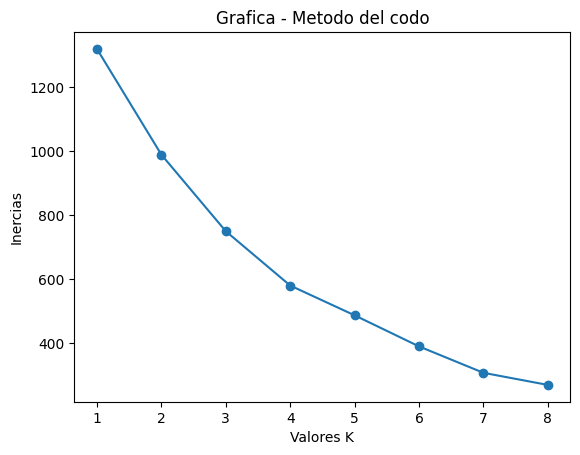

In [ ]:
# Grafica de la curva
rango_k = [1,2,3,4,5,6,7,8]
plt.plot(rango_k, inercias, marker='o')
plt.xlabel('Valores K')
plt.ylabel('Inercias')
plt.title('Grafica - Metodo del codo')
plt.show()

##4.3 Calcula el silhouette score para cada k

In [ ]:
# Silhouette score en cada k
scores = []
for k in range(2, 9):
    silhouette = silhouette_score(X_scaled, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled))
    scores.append(silhouette)
    print(f'k={k}: silhouette={silhouette:.2f}')

k=2: silhouette=0.48
k=3: silhouette=0.46
k=4: silhouette=0.43
k=5: silhouette=0.35
k=6: silhouette=0.41
k=7: silhouette=0.40
k=8: silhouette=0.34


In [ ]:
# KMeans 2
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster_k2'] = kmeans_k2.fit_predict(X_scaled)
df['cluster_k2'].value_counts().sort_index()
#pd.crosstab(df['cluster_k2'], df['Channel'])
#df.groupby('cluster_k2')[['Fresh', 'Frozen', 'Grocery']].mean().round(2)

,count
cluster_k2,
0,368
1,72


In [ ]:
# KMeans 4
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_k4'] = kmeans_k4.fit_predict(X_scaled)
df['cluster_k4'].value_counts().sort_index()

,count
cluster_k4,
0,307
1,50
2,3
3,80


##4.4 Elige tu k final basándote en ambas métricas, no "a ojo"

Justificación escrita: ¿qué k elegiste y qué mostraron el codo y el silhouette score para justificar esa elección? Si ambas métricas no coinciden en el mismo k, explica cuál priorizaste y por qué.

###¿qué k elegiste y qué mostraron el codo y el silhouette score para justificar esa elección?
* Se eligio K4, la grafica del codo mostro que en k4 empieza a marcarse el codo, mientras que en silhouette mostro que k2 tenia el mayor valor, pero al estar divido el cluster en solo dos grupos la division podria mostrar una segmentacion muy basica y no mostrar informacion que podria ser relevante como lo seria en un cluster dividido en 4 grupos.

#Paso 5 — Clustering jerárquico (para contrastar)
## 5.1 Genera un dendrograma con linkage (método ward)

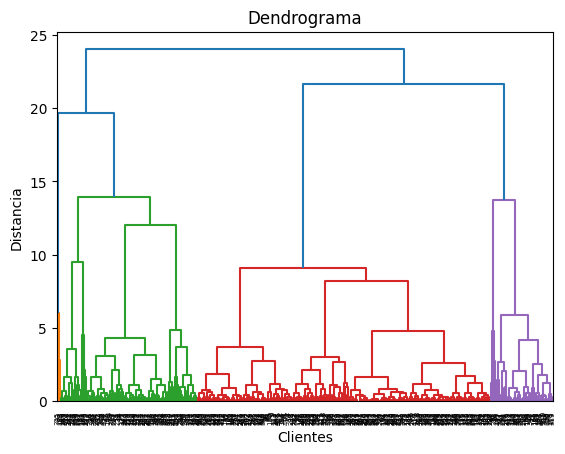

In [ ]:
# Generar Dendrograma con linkage
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_data = linkage(X_scaled, method='ward')
dendrogram(linkage_data)
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()

##5.2 Corta el árbol para obtener la misma cantidad de clusters que elegiste en el Paso 4

In [ ]:
from sklearn.cluster import AgglomerativeClustering

dendro4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_dendro4'] = dendro4.fit_predict(X_scaled)
df['cluster_dendro4'].value_counts().sort_index()

,count
cluster_dendro4,
0,122
1,55
2,260
3,3


##5.3 Compara el tamaño de cada cluster contra los de K-Means

In [ ]:
print(df['cluster_dendro4'].value_counts().sort_index())
print(df['cluster_k4'].value_counts().sort_index())
#
pd.crosstab(df['cluster_k4'], df['cluster_dendro4'])

cluster_dendro4
0    122
1     55
2    260
3      3
Name: count, dtype: int64
cluster_k4
0    307
1     50
2      3
3     80
Name: count, dtype: int64


cluster_dendro4,0,1,2,3
cluster_k4,,,,
0,42,7,258,0
1,0,48,2,0
2,0,0,0,3
3,80,0,0,0


Justificación escrita: ¿los grupos que forma el clustering jerárquico son parecidos a los
de K-Means o muy distintos? ¿A qué crees que se debe eso?

##¿Los grupos que forma el clustering jerárquico son parecidos a los de K-Means o muy distintos?
* En el grupo de clustering jerarquico hay un cluster parecido al de Kmeans ambos son el cluster 1 (55 y 50) y tambien existe el mismo grupo en ambos solo que en el jerarquico es el cluster 3 y en Kmeans es el cluster 2 (3 y 3).

##¿A qué crees que se debe eso?
* el cluster 1 jerarquico (55) y el cluster 1 kmeans (50) deben tener un patron parecido que identifico en ambos metodos. Y el cluster 3 jerarquico y el cluster 2 kmeans son el mismo pero calculados con distintos metodos

#Paso 6 — DBSCAN y detección de outliers
##6.1 Prueba DBSCAN con al menos 3 combinaciones de eps y min_samples

In [ ]:
# Aplicar DBSCAN
eps = [0.3, 0.5, 0.7, 0.9]
#min_samples = [3, 6, 9]
dbscan = []

for k in range (0, 4):
  dbscan_res = DBSCAN(eps=eps[k], min_samples=3)
  dbscan.append(dbscan_res.fit(X_scaled))
  print(pd.Series(dbscan[k].labels_).value_counts())



 0    336
-1     73
 1      7
 3      5
 7      4
 2      3
 6      3
 4      3
 5      3
 8      3
Name: count, dtype: int64
 0    389
-1     37
 1      7
 3      4
 2      3
Name: count, dtype: int64
 0    411
-1     24
 1      5
Name: count, dtype: int64
 0    426
-1     14
Name: count, dtype: int64


##6.2 Para cada combinación, reporta cuántos clusters y cuántos outliers (-1) detecta
* Para la primera combinacion de eps=0.3, min_samples=3 encuentra 9 clusters con 73 outlier (-1)
* Para la segunda combinacion de eps=0.5, min_samples=3 encuentra 4 clusters con 37 outlier (-1)
* Para la tercera combinacion de eps=0.7, min_samples=3 encuentra 2 clusters con 24 outlier (-1)
* Para la cuarta combinacion de eps=0.9 min_samples=3 encuentra 1 clusters con 14 outlier (-1)

##6.3 Elige la configuración final que te parezca más razonable

- Configuracion elegida: eps=0.5, min_samples=3

Justificación escrita: ¿cuántos outliers detectó tu configuración final? Revisa esas filas
específicas — ¿tiene sentido que sean atípicas dado lo que sabés del tema? Si DBSCAN
no encontró ningún outlier, explica por qué crees que pasó eso con tus datos.

##¿cuántos outliers detectó tu configuración final?
En la configuracion final se encontraron 37 outliers

##¿tiene sentido que sean atípicas dado lo que sabés del tema?
Probablemente, los 37 outliers tienen en promedio más del doble de gasto que el cliente tipico en las 3 categorias. Clientes que tambien eran outliers en Kmeans tambien aparecen como outlier en DBSCAN


#Paso 7 — Reducción de dimensionalidad y visualización
##7.1 Aplica PCA a 2 componentes sobre tus variables escaladas

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

##7.2 Reporta cuánta varianza explica cada componente (y el total)

In [ ]:
print(pca.explained_variance_ratio_.round(3))
print("Varianza total:", pca.explained_variance_ratio_.sum().round(3))

[0.45  0.332]
Varianza total: 0.782


##7.3 Grafica tus clusters finales (de K-Means) en el espacio de 2 componentes de PCA, coloreados por cluster

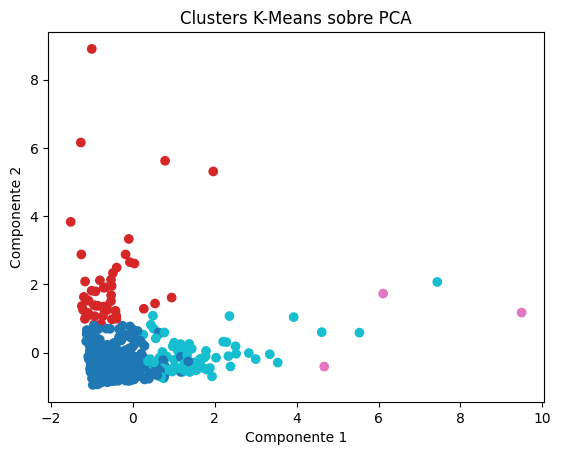

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster_k4'], cmap='tab10')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Clusters K-Means sobre PCA')
plt.show()

Justificación escrita: ¿qué porcentaje de la información original conservan tus 2 componentes? Con ese dato, ¿confiarías en lo que se ve en el gráfico 2D, o te parece que se pierde demasiada información?

##¿qué porcentaje de la información original conservan tus 2 componentes?

##¿confiarías en lo que se ve en el gráfico 2D, o te parece que se pierde demasiada información?


#Paso 8 — Perfil de cada cluster y conclusiones
##8.1 Calcula la media de cada variable original (sin escalar) por cluster

##8.2 Nombra cada cluster con una etiqueta descriptiva de negocio (ej. "clientes frecuentes de bajo gasto")

Escribe un párrafo final (5-8 líneas) que responda:
• ¿Qué caracteriza a cada cluster que encontraste?
• ¿Los clusters que obtuviste coinciden con tu intuición inicial del Paso 1, o te sorprendió algo?
• Si tuvieras que usar estos clusters para una decisión real (una campaña, una
intervención, una política), ¿qué acción propondrías para cada grupo?
• ¿Qué limitación tiene tu análisis? ¿Qué variable adicional te hubiera gustado tener?

-